# Relative Serial Recall Accuracy

> Measure how often each recall follows its immediate study predecessor.

The relative serial recall accuracy curve scores a recall as correct when it immediately follows its predecessor in the study list. The first recall is scored relative to position 0, so only study position 1 counts as correct at the first output slot. This measure highlights how well participants maintain local order during retrieval.

This notebook is parameterized for use with [papermill](https://papermill.readthedocs.io/).

| Parameter | Description |
|-----------|-------------|
| `data_path` | Path to HDF5 dataset file |
| `figure_dir` | Directory for saving figures |
| `figure_str` | Filename for saved figure (empty string to skip saving) |
| `ylim` | Y-axis limits as tuple, or `None` for auto |
| `trial_query` | Query string for trial selection |

: Notebook parameters {#tbl-parameters}

In [1]:
#| include: false
from nbdev.showdoc import show_doc

In [2]:
#| code-summary: Imports and setup
import os
import warnings

import jax.numpy as jnp
import matplotlib.pyplot as plt

from jaxcmr.analyses.relative_srac import (
    plot_relative_srac,
    relative_srac,
    tabulate_trial,
)
from jaxcmr.helpers import find_project_root, generate_trial_mask, load_data

warnings.filterwarnings("ignore")


def save_figure(figure_dir, figure_str, suffix=None):
    plt.tight_layout()
    if not figure_str:
        plt.show()
        return
    os.makedirs(figure_dir, exist_ok=True)
    suffix_str = f"_{suffix}" if suffix else ""
    figure_path = os.path.join(figure_dir, f"{figure_str}{suffix_str}.png")
    plt.savefig(figure_path, bbox_inches="tight", dpi=600)
    plt.show()

In [3]:
#| code-summary: Parameters for this analysis

data_path = "data/Gordon2021.h5"
figure_dir = "results/figures"
figure_str = ""
ylim = None
trial_query = "data['condition'] == 2"

In [4]:
#| code-summary: Load data and generate trial mask
project_root = find_project_root()
figure_dir = os.path.join(project_root, figure_dir)
data_path = os.path.join(project_root, data_path)
data = load_data(data_path)
trial_mask = generate_trial_mask(data, trial_query)

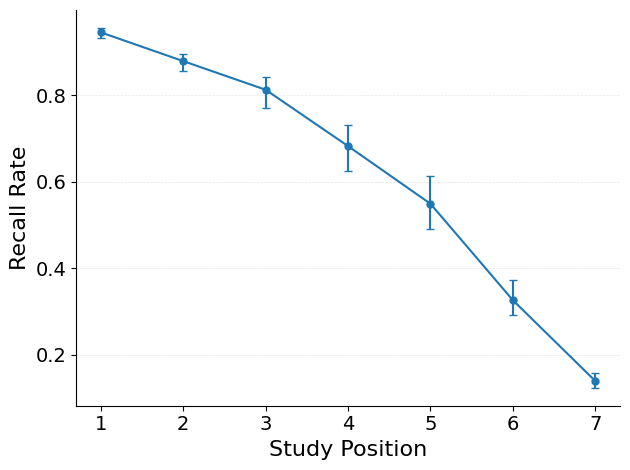

In [5]:
#| code-summary: Plot relative serial recall accuracy
#| label: fig-relative-srac
#| fig-cap: "Relative serial recall accuracy by study position."
plot_relative_srac(datasets=data, trial_masks=trial_mask)
if ylim is not None:
    for ax in plt.gcf().axes:
        ax.set_ylim(ylim)
save_figure(figure_dir, figure_str)

---

## Reference

In [6]:
#| echo: false
show_doc(plot_relative_srac)

---

### plot_relative_srac

>      plot_relative_srac (datasets:Union[Sequence[jaxcmr.typing.RecallDataset],
>                          jaxcmr.typing.RecallDataset], trial_masks:Union[Seque
>                          nce[jaxtyping.Bool[Array,'trial_count']],jaxtyping.Bo
>                          ol[Array,'trial_count']],
>                          color_cycle:Optional[list[str]]=None,
>                          labels:Optional[Sequence[str]]=None,
>                          contrast_name:Optional[str]=None,
>                          axis:Optional[matplotlib.axes._axes.Axes]=None,
>                          size:int=3, confidence_level:float=0.95)

*Plot relative serial recall accuracy with intervals.*

|    | **Type** | **Default** | **Details** |
| -- | -------- | ----------- | ----------- |
| datasets | Union |  | One or more datasets to plot. |
| trial_masks | Union |  | Boolean mask(s) selecting trials. |
| color_cycle | Optional | None | Colors for each curve. |
| labels | Optional | None | Legend labels for each curve. |
| contrast_name | Optional | None | Legend title. |
| axis | Optional | None | Existing Axes to plot on. |
| size | int | 3 | Max study positions an item can occupy. |
| confidence_level | float | 0.95 | Confidence level for error bounds. |
| **Returns** | **Axes** |  | **Matplotlib Axes with the relative SRAC plot.** |

In [7]:
#| echo: false
show_doc(relative_srac)

---

### relative_srac

>      relative_srac (dataset:jaxcmr.typing.RecallDataset, size:int=3)

*Relative serial recall accuracy by study position.*

|    | **Type** | **Default** | **Details** |
| -- | -------- | ----------- | ----------- |
| dataset | RecallDataset |  | Recall dataset with ``recalls`` and ``pres_itemnos``. |
| size | int | 3 | Max study positions an item can occupy. |
| **Returns** | **Float[Array, 'study_positions']** |  | **Mean accuracy at each study position.** |

In [8]:
# Perfect forward recall scores 1.0 at every position
recalls = jnp.array([[1, 2, 3], [1, 2, 3]], dtype=jnp.int32)
presentations = jnp.array([[1, 2, 3], [1, 2, 3]], dtype=jnp.int32)

dataset = {
    "subject": jnp.ones((2, 1), dtype=jnp.int32),
    "listLength": jnp.full((2, 1), 3, dtype=jnp.int32),
    "pres_itemnos": presentations,
    "recalls": recalls,
}

scores = relative_srac(dataset)
assert jnp.allclose(scores, jnp.array([1.0, 1.0, 1.0]))

In [9]:
#| echo: false
show_doc(tabulate_trial)

---

### tabulate_trial

>      tabulate_trial (trial:jaxtyping.Integer[Array,'recall_events'],
>                      presentation:jaxtyping.Integer[Array,'study_events'],
>                      size:int=3)

*Flag study positions where recall follows its predecessor.*

|    | **Type** | **Default** | **Details** |
| -- | -------- | ----------- | ----------- |
| trial | Integer[Array, 'recall_events'] |  | 1-indexed recalls; 0 pads unused events. |
| presentation | Integer[Array, 'study_events'] |  | Item IDs in study order. |
| size | int | 3 | Max study positions an item can occupy. |
| **Returns** | **Float[Array, 'study_events']** |  | **True at positions recalled after their neighbor.** |

In [10]:
# Out-of-order start: only the +1 transition (2->3) is flagged
flags = tabulate_trial(
    jnp.array([2, 3, 1], dtype=jnp.int32),
    jnp.array([1, 2, 3], dtype=jnp.int32),
)
assert jnp.array_equal(flags, jnp.array([False, False, True]))